## SNOTEL QC Development
Evaluate some approaches to doing QC on SNOTEL data.

In [1]:
%matplotlib ipympl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date, time
from buildforcing.datasets import PNNLSnotel
import os

In [2]:
site = 'Quemazon'

### Load Data
I only care about the range of data used in the downscaling, so I'll limit the data to that range using the find_usable_dates function from buildforcing.

In [3]:
snotel = PNNLSnotel(site_name=site, storage_path=os.environ['SNOTEL_PATH'])
snotel.load_data()

# print latitude and longitude for reference
print(f"Latitude: {snotel.latitude}, Longitude: {snotel.longitude}")

Latitude: 35.92, Longitude: -106.39


In [4]:
start_date, end_date = snotel.find_usable_dates()
print(f"Usable dates: {start_date} to {end_date}")

Usable dates: 1989-10-01 to 2021-09-30


In [5]:
# Extract SNOTEL data for the usable date range or starting in 1990, whichever is later
if start_date < date(1990, 1, 1):
    start_date = date(1990, 1, 1)

snotel_data = snotel.data[start_date.strftime('%Y-%m-%d'):end_date.strftime('%Y-%m-%d')]

I think most of the datasets are daily with Nans for missing data, but it seems reasonable to ensure that is the case.

In [6]:
# Ensure index is daily
snotel_data = snotel_data.asfreq('D')

#### Visualization

In [7]:
# Calculate F temperatures for easier analysis
snotel_data['T_max_F'] = snotel_data['T_max_C'] * 9/5 + 32
snotel_data['T_min_F'] = snotel_data['T_min_C'] * 9/5 + 32
snotel_data['T_avg_F'] = snotel_data['T_avg_C'] * 9/5 + 32

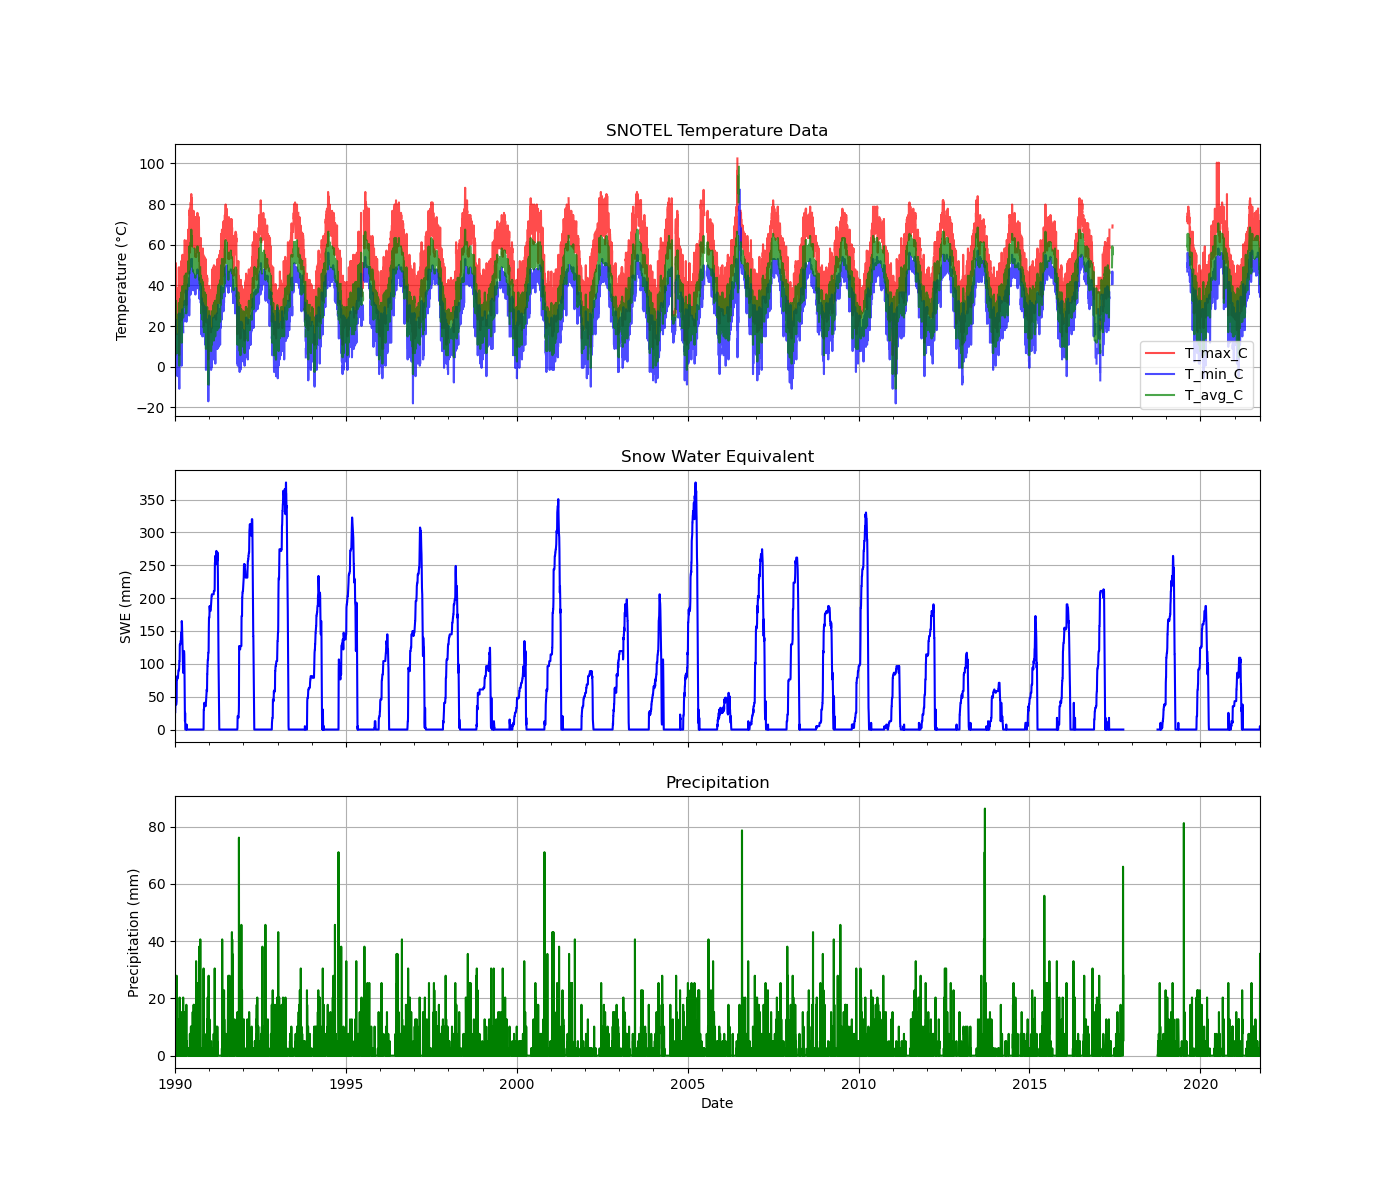

In [8]:
# Create a single figure with 3 subplots (temperature, SWE, precipitation)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot temperatures in the top subplot
snotel_data['T_max_F'].plot(ax=ax1, label='T_max_C', color='red', alpha=0.7)
snotel_data['T_min_F'].plot(ax=ax1, label='T_min_C', color='blue', alpha=0.7)
snotel_data['T_avg_F'].plot(ax=ax1, label='T_avg_C', color='green', alpha=0.7)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('SNOTEL Temperature Data')
ax1.legend()
ax1.grid(True)

# Plot SWE in the middle subplot
ax2.plot(snotel_data.index, snotel_data['swe_mm'], color='blue')
ax2.set_ylabel('SWE (mm)')
ax2.set_title('Snow Water Equivalent')
ax2.grid(True)

# Plot Precipitation in the bottom subplot
ax3.plot(snotel_data.index, snotel_data['precip_mm'], color='green')
ax3.set_xlabel('Date')
ax3.set_ylabel('Precipitation (mm)')
ax3.set_title('Precipitation')
ax3.grid(True)

plt.show()

Extract sections of interest for manual review.

In [17]:
test_start_date = '2017-01-01'
test_end_date = '2020-12-01'

In [9]:
test_section = snotel_data.loc['2017-01-01':'2020-12-01', ['T_max_C', 'T_min_C', 'T_avg_C']]

### QC approaches
I'll start by flagging values, then decide if I want to remove them or fill them later.

In [10]:
# I can't use days with only a max or a min. Set those to NaN for now.
test_section.loc[test_section['T_max_C'].isna() | test_section['T_min_C'].isna(), ['T_max_C', 'T_min_C', 'T_avg_C']] = np.nan

#### Check 1.
Ensure consistency between temperature variables (T_max, T_min, T_avg).
- T_max should always be >= T_min
- T_avg should always be between T_max and T_min
- Diurnal temperature range (T_max - T_min) should be reasonable. At the least, I think it should be > 5 degrees C. 

In [11]:
test_section['bad_max_min'] = (test_section['T_max_C'] - test_section['T_min_C']) < 5
#test_section['avg_not_between'] = ~test_section['T_avg_C'].between(test_section['T_min_C'], test_section['T_max_C'])

I have found data where the average is clearly bad, but the the max and min are reasonable. If I don't know if the average is good, I can't use it because it will create false flags.

In [12]:
#test_section['flagged'] = test_section['bad_max_min'] | test_section['avg_not_between']
test_section['flagged'] = test_section['bad_max_min']

In [13]:
test_clean = test_section[test_section['flagged'] == False]

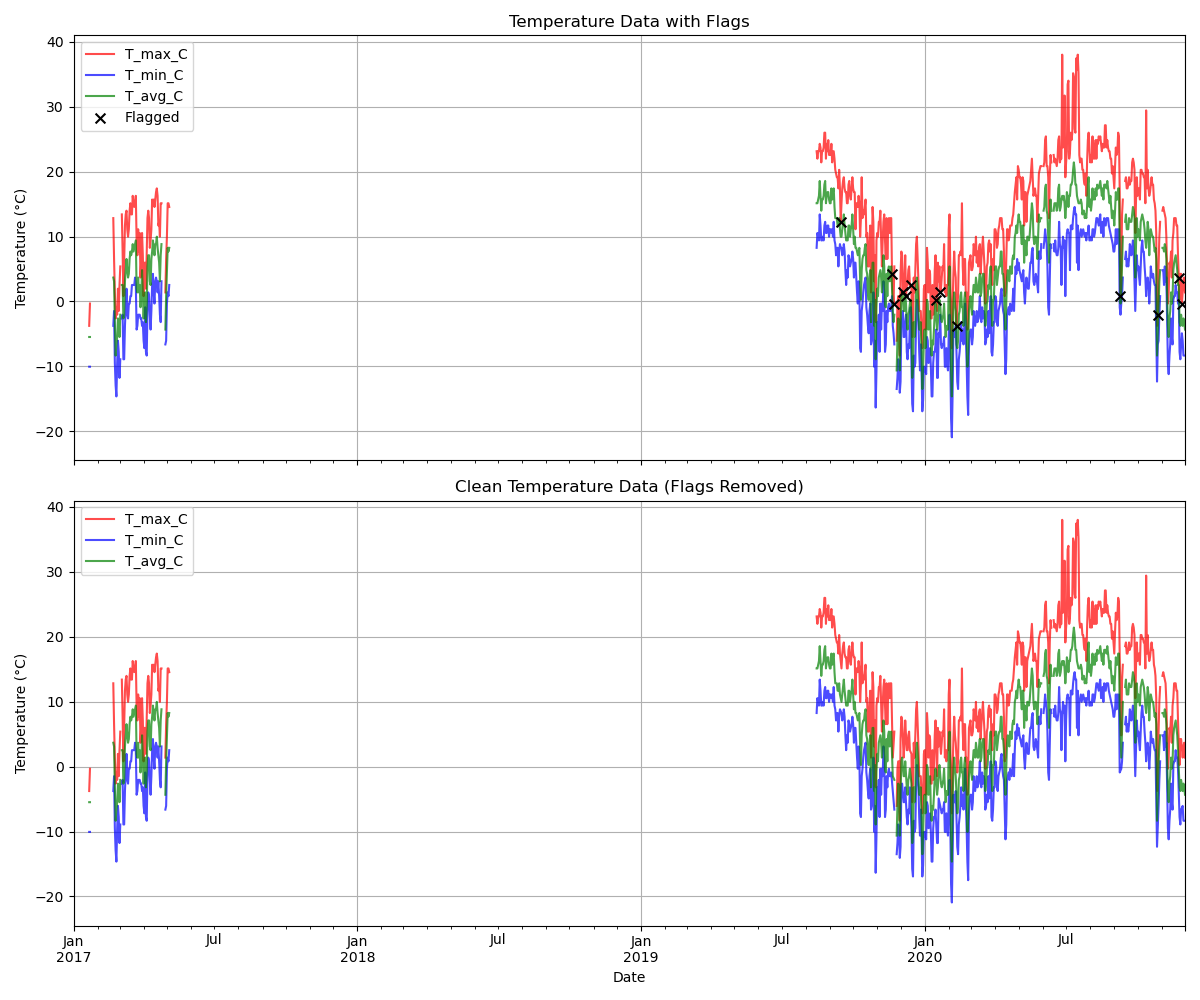

In [14]:
# Plot test section with flags and clean data in two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot test section with flags in the top subplot
test_section['T_max_C'].plot(ax=ax1, label='T_max_C', color='red', alpha=0.7)
test_section['T_min_C'].plot(ax=ax1, label='T_min_C', color='blue', alpha=0.7)
test_section['T_avg_C'].plot(ax=ax1, label='T_avg_C', color='green', alpha=0.7)
ax1.scatter(test_section.index[test_section['flagged']], test_section['T_max_C'][test_section['flagged']], 
           color='black', marker='x', s=50, label='Flagged', zorder=5)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Temperature Data with Flags')
ax1.legend()
ax1.grid(True)

# Plot clean data in the bottom subplot
test_clean['T_max_C'].plot(ax=ax2, label='T_max_C', color='red', alpha=0.7)
test_clean['T_min_C'].plot(ax=ax2, label='T_min_C', color='blue', alpha=0.7)
test_clean['T_avg_C'].plot(ax=ax2, label='T_avg_C', color='green', alpha=0.7)
ax2.set_ylabel('Temperature (°C)')
ax2.set_xlabel('Date')
ax2.set_title('Clean Temperature Data (Flags Removed)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

In [15]:
# Baldy specific for testing...
# Flag all data between Dec 1992 and Aug 1993 as bad
#test_section.loc['1992-12-01':'1993-08-01', 'flagged'] = True

# Copy and set all flagged data to NaN for analysis
test_clean = test_section.copy()
test_clean.loc[test_clean['flagged'], ['T_max_C', 'T_min_C', 'T_avg_C']] = np.nan

## Gap Filling
Explore filling gaps in data with NLDAS

In [16]:
from buildforcing.datasets import siteNLDAS

For this investigation, I will just load a subset of the NLDAS data so that I can assess methods.

In [18]:
start_dt = datetime.strptime(test_start_date, '%Y-%m-%d')
end_dt = datetime.strptime(test_end_date, '%Y-%m-%d')
nldas = siteNLDAS(snotel.latitude, snotel.longitude, start_date=start_dt, end_date=end_dt)

In [19]:
nldas.loadNetCDF(os.environ['NLDAS_PATH'])

In [ ]:
nldas.data.head()

Initial evaluation of simply filling gaps with NLDAS

In [20]:
# Adjust timezone if needed (e.g., for MST, UTC-7)
nldas_snoteltz = nldas.data.tz_convert(test_clean.index.tz)

# Calculate daily max and min temperatures from hourly NLDAS data
nldas_daily = nldas_snoteltz.resample('D').agg({'Tair': ['max', 'min']})
nldas_daily = nldas_daily - 273.15  # Convert from Kelvin to Celsius

# Rename columns for clarity
nldas_daily.columns = ['Tair_max', 'Tair_min']

It appears that an average shift in the NLDAS data will fill gaps reasonably well.

In [ ]:
nldas_daily.index

In [21]:
# Merge SNOTEL and NLDAS temperatures for analysis
merged_temps = pd.merge(test_clean[['T_max_C', 'T_min_C']], nldas_daily[['Tair_max', 'Tair_min']], left_index=True, right_index=True, how='inner')

In [22]:
# Calculate difference between SNOTEL and NLDAS temperatures
merged_temps['T_max_diff'] = merged_temps['T_max_C'] - merged_temps['Tair_max']
merged_temps['T_min_diff'] = merged_temps['T_min_C'] - merged_temps['Tair_min']

In [23]:
# Calculate average differences
avg_max_diff = merged_temps['T_max_diff'].mean()
avg_min_diff = merged_temps['T_min_diff'].mean()

In [24]:
# Fill missing data from test_clean with offset NLDAS data
test_filled = test_clean.copy()
test_filled['T_max_C'] = test_filled['T_max_C'].fillna(nldas_daily['Tair_max'] + avg_max_diff)
test_filled['T_min_C'] = test_filled['T_min_C'].fillna(nldas_daily['Tair_min'] + avg_min_diff)

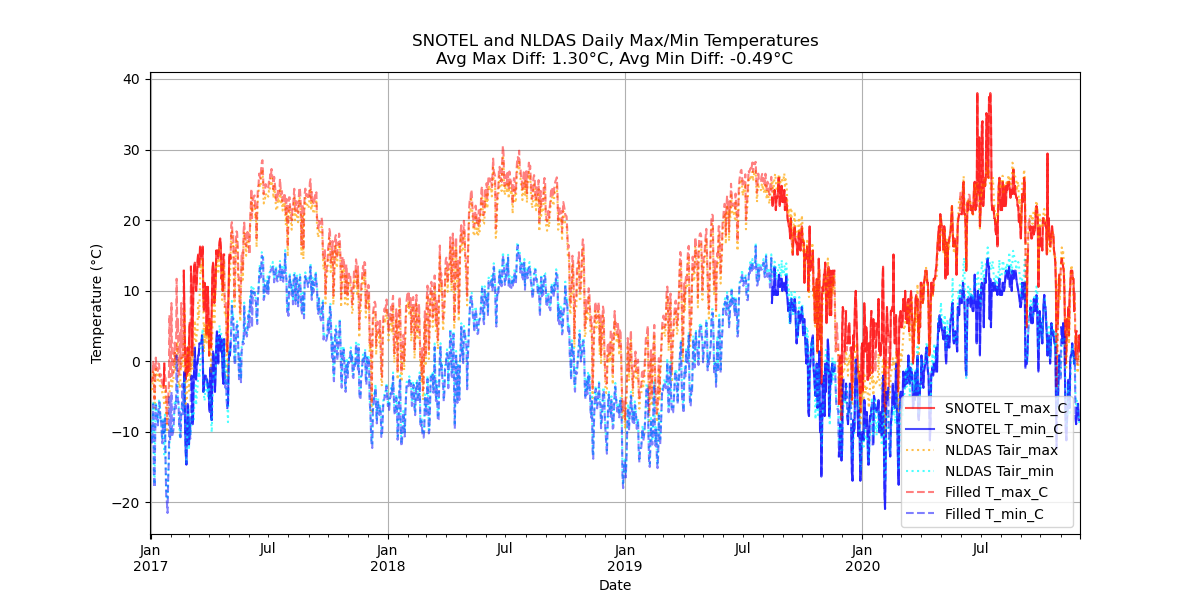

In [25]:
# Plot NLDAS max and min temperatures with SNOTEL data
fig, ax = plt.subplots(figsize=(12, 6))

# Plot SNOTEL data with solid lines
test_clean['T_max_C'].plot(ax=ax, label='SNOTEL T_max_C', color='red', alpha=0.7)
test_clean['T_min_C'].plot(ax=ax, label='SNOTEL T_min_C', color='blue', alpha=0.7)

# Plot NLDAS data with dotted lines
nldas_daily['Tair_max'].plot(ax=ax, label='NLDAS Tair_max', color='orange', linestyle=':', alpha=0.7)
nldas_daily['Tair_min'].plot(ax=ax, label='NLDAS Tair_min', color='cyan', linestyle=':', alpha=0.7)

# Plot filled data with dashed lines
test_filled['T_max_C'].plot(ax=ax, label='Filled T_max_C', color='red', linestyle='--', alpha=0.5)
test_filled['T_min_C'].plot(ax=ax, label='Filled T_min_C', color='blue', linestyle='--', alpha=0.5)

# Add grid and labels
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'SNOTEL and NLDAS Daily Max/Min Temperatures\nAvg Max Diff: {avg_max_diff:.2f}°C, Avg Min Diff: {avg_min_diff:.2f}°C')
ax.grid(True)
ax.legend()